In [1]:
import cupy as cp
import numpy

def cov_matern(d, loghyper, x):
    ell = cp.exp(loghyper[0])
    sf2 = cp.exp(2 * loghyper[1])
    def f(t):
        if d == 1: return 1
        if d == 3: return 1 + t
        if d == 5: return 1 + t * (1 + t / 3)
        if d == 7: return 1 + t * (1 + t * (6 + t) / 15)
    def m(t):
        return f(t) * cp.exp(-t)
    dist_sq = ((x[:, None] - x[None, :]) / ell) ** 2
    return sf2 * m(cp.sqrt(d * dist_sq))

def bohman(loghyper, x):
    range_ = cp.exp(loghyper[0])
    dis = cp.abs(x[:, None] - x[None, :])
    r = cp.minimum(dis / range_, 1)
    k = (1 - r) * cp.cos(cp.pi * r) + cp.sin(cp.pi * r) / cp.pi
    k[k < 1e-16] = 0
    k[cp.isnan(k)] = 0
    return k

def unfold(tensor, mode):
    return cp.reshape(cp.moveaxis(tensor, mode, 0), (tensor.shape[mode], -1), order='F')

def fold(mat, dim, mode):
    index = [mode] + [i for i in range(dim.shape[0]) if i != mode]
    return cp.moveaxis(cp.reshape(mat, list(dim[index]), order='F'), 0, mode)

# ── Factor-matrix CG ──────────────────────────────────────────────────────────

def Ap_operatorT(vec, maskT, KrU, KrU_T, Qu, rho, R, M):
    X = vec.reshape(R, M, order='F')
    temp = KrU @ X
    temp *= maskT
    Ap1 = KrU_T @ temp
    Ap2 = rho * (X @ Qu)
    return (Ap1 + Ap2).ravel(order='F')

def cg_factorT(Qu, rho, KrU, mask_matrixT, YR_tilde, priorvalue, max_iter=30):
    R, M = YR_tilde.shape
    Y_flat = YR_tilde.ravel(order='F')
    x = priorvalue.copy()
    KrU_T = KrU.T
    Ax = Ap_operatorT(x, mask_matrixT, KrU, KrU_T, Qu, rho, R, M)
    r = Y_flat - Ax
    p = r.copy()
    rsold = cp.dot(r, r)
    approxE = cp.zeros(max_iter)
    for i in range(max_iter):
        Ap = Ap_operatorT(p, mask_matrixT, KrU, KrU_T, Qu, rho, R, M)
        alpha = rsold / cp.dot(p, Ap)
        x += alpha * p
        r -= alpha * Ap
        rsnew = cp.dot(r, r)
        approxE[i] = cp.sqrt(rsnew)
        if float(approxE[i]) < 1e-4:
            break
        p = r + (rsnew / rsold) * p
        rsold = rsnew
    return x, approxE[:i+1]

# ── Local-component CG with precomputed rfft spectra (GPU) ───────────────────

def _embed_circulant_rfft(col, fft_len):
    """Embed Toeplitz first column into circulant and compute rfft once (on GPU)."""
    c = cp.concatenate([col, cp.array([0.0]), col[:0:-1]])
    c_padded = cp.pad(c, (0, fft_len - len(c)))
    return cp.fft.rfft(c_padded)

def _toeplitz_rfft_mv_batch(col_rfft, fft_len, n, X):
    """Toeplitz matvec via precomputed rfft spectrum (GPU batch)."""
    X_padded = cp.pad(X, ((0, fft_len - n), (0, 0)))
    return cp.fft.irfft(col_rfft[:, None] * cp.fft.rfft(X_padded, axis=0),
                        n=fft_len, axis=0)[:n]

def kronecker_fft_precomputed(K3, K2_rfft, fft_len2, K1_rfft, fft_len1, vec, d1, d2, d3):
    """Kronecker (K3 ⊗ K2 ⊗ K1) matvec using precomputed rfft spectra for K1, K2."""
    X = vec.reshape((d1, d2, d3), order='F')
    # mode-1
    X = _toeplitz_rfft_mv_batch(K1_rfft, fft_len1, d1,
                                 X.reshape(d1, -1)).reshape(d1, d2, d3)
    # mode-2
    X = _toeplitz_rfft_mv_batch(K2_rfft, fft_len2, d2,
                                 X.transpose(1, 0, 2).reshape(d2, -1)).reshape(d2, d1, d3).transpose(1, 0, 2)
    # mode-3 (3×3, direct dense multiply)
    X = cp.tensordot(X, K3, axes=([2], [0]))
    return X.ravel(order='F')

def Ap_operatorL(vec, pos_obs, K3, K2_rfft, fft_len2, K1_rfft, fft_len1, gamma, x_buf, d1, d2, d3):
    x_buf[:] = 0.0
    x_buf[pos_obs] = vec
    Ap1 = kronecker_fft_precomputed(K3, K2_rfft, fft_len2, K1_rfft, fft_len1, x_buf, d1, d2, d3)
    return Ap1[pos_obs] + gamma * vec

def cg_local(gamma, K3, K2_rfft, fft_len2, K1_rfft, fft_len1,
             pos_obs, YR_tilde, priorvalue, x_buf, max_iter=50):
    d1, d2, d3 = YR_tilde.shape
    Y_obs = YR_tilde.ravel(order='F')[pos_obs]
    x = priorvalue.copy()
    Ax = Ap_operatorL(x, pos_obs, K3, K2_rfft, fft_len2, K1_rfft, fft_len1, gamma, x_buf, d1, d2, d3)
    r = Y_obs - Ax
    p = r.copy()
    rsold = cp.dot(r, r)
    approxE = cp.zeros(max_iter)
    for i in range(max_iter):
        Ap = Ap_operatorL(p, pos_obs, K3, K2_rfft, fft_len2, K1_rfft, fft_len1, gamma, x_buf, d1, d2, d3)
        alpha = rsold / cp.dot(p, Ap)
        x += alpha * p
        r -= alpha * Ap
        rsnew = cp.dot(r, r)
        approxE[i] = cp.sqrt(rsnew)
        if float(approxE[i]) < 1e-4:
            break
        p = r + (rsnew / rsold) * p
        rsold = rsnew
    return x, approxE[:i+1]


In [2]:
from cupyx.scipy.linalg import khatri_rao

def GLSKF(I, Omega, lengthscaleU, lengthscaleR, varianceU, varianceR,
          tapering_range, d_MaternU, d_MaternR, R, rho, gamma,
          maxiter, K0, epsilon):
    N = numpy.array(I.shape)
    D = I.ndim
    maxP = float(cp.max(I))

    Omega = Omega.astype(bool)
    pos_miss = cp.where(Omega == 0)
    num_obser = cp.sum(Omega)
    mask_matrix  = [unfold(Omega, d) for d in range(D)]
    mask_matrixT = [mm.T for mm in mask_matrix]
    mask_flat    = [mm.ravel(order='F') for mm in mask_matrix]
    pos_obs      = [cp.where(mf == 1) for mf in mask_flat]
    idx = cp.sum(mask_matrix[2], axis=0) > 0

    train_matrix = I * Omega
    train_matrix = train_matrix[train_matrix > 0]
    Isubmean = I - cp.mean(train_matrix)
    T = Isubmean * Omega

    hyper_Ku = [[cp.log(lengthscaleU[d]), cp.log(varianceU[d])] for d in range(2)]
    hyper_Kr = [[cp.log(lengthscaleR[d]), cp.log(varianceR[d]), cp.log(tapering_range)]
                for d in range(2)]

    Ku, Kr = [None] * D, [None] * D
    invKu  = [None] * D

    x = cp.arange(1, N[0] + 1, dtype=cp.float64)
    Ku[0]    = cov_matern(d_MaternU, hyper_Ku[0], x)
    invKu[0] = cp.linalg.inv(Ku[0])
    TaperM   = bohman([hyper_Kr[0][2]], x)
    Kr[0]    = cov_matern(d_MaternR, hyper_Kr[0][:2], x) * TaperM

    x = cp.arange(1, N[1] + 1, dtype=cp.float64)
    Ku[1]    = cov_matern(d_MaternU, hyper_Ku[1], x)
    invKu[1] = cp.linalg.inv(Ku[1])
    TaperM   = bohman([hyper_Kr[1][2]], x)
    Kr[1]    = cov_matern(d_MaternR, hyper_Kr[1][:2], x) * TaperM

    invKu[2] = cp.eye(N[2])
    Kr[2]    = cp.eye(N[2])

    # ── precompute rfft spectra for the two large Toeplitz kernels ──────────
    d1, d2, d3 = int(N[0]), int(N[1]), int(N[2])
    fft_len1 = 2 * d1
    fft_len2 = 2 * d2
    Kr0_rfft = _embed_circulant_rfft(Kr[0][:, 0], fft_len1)   # fixed throughout
    Kr1_rfft = _embed_circulant_rfft(Kr[1][:, 0], fft_len2)   # fixed throughout
    x_buf    = cp.zeros(d1 * d2 * d3)                          # reused scatter buffer

    X = T.copy()
    X[pos_miss] = T.sum() / num_obser
    #U = [0.1 * cp.random.randn(N[d], R) for d in range(D)]
    U = [cp.array(0.1 * numpy.random.randn(N[d], R)) for d in range(D)]
    M_unfold1 = U[0] @ khatri_rao(U[2], U[1]).T
    M = fold(M_unfold1, N, 0)
    UTvector     = [U[d].T.ravel(order='F') for d in range(D)]
    Rtensor      = cp.zeros(tuple(N))
    Rvector_temp = cp.zeros(d1 * d2 * d3)
    X[pos_miss]  = M[pos_miss] + Rtensor[pos_miss]

    d_all      = numpy.arange(D)
    train_norm = cp.linalg.norm(T)
    last_ten   = T.copy()
    psnrf      = cp.zeros(maxiter)
    approxU    = [None] * D
    it = 0

    while True:
        Gtensor      = X - Rtensor
        Gtensor_mask = Gtensor * Omega
        Gtensor_unfold = [unfold(Gtensor_mask, d) for d in range(D)]

        for d in range(D):
            dsub = numpy.delete(d_all, d)
            KrU  = khatri_rao(U[dsub[1]], U[dsub[0]])
            HG   = KrU.T @ Gtensor_unfold[d].T
            UTvector[d], approxU[d] = cg_factorT(
                invKu[d], rho, KrU, mask_matrixT[d], HG, UTvector[d])
            U[d] = UTvector[d].reshape(R, N[d], order='F').T

        M_unfold1 = U[0] @ khatri_rao(U[2], U[1]).T
        M = fold(M_unfold1, N, 0)
        X[pos_miss] = M[pos_miss] + Rtensor[pos_miss]

        if it >= K0:
            Ltensor_mask = (X - M) * Omega
            Rvector_temp[pos_obs[0]], approxE = cg_local(
                gamma, Kr[2],
                Kr1_rfft, fft_len2, Kr0_rfft, fft_len1,
                pos_obs[0], Ltensor_mask, Rvector_temp[pos_obs[0]], x_buf)
            Rvector = kronecker_fft_precomputed(
                Kr[2], Kr1_rfft, fft_len2, Kr0_rfft, fft_len1,
                Rvector_temp, d1, d2, d3)
            Rtensor = Rvector.reshape(tuple(N), order='F')
            Rtensor_unfold3_obs = unfold(Rtensor, 2)[:, idx]
            Kr[2] = cp.cov(Rtensor_unfold3_obs)
        else:
            Rtensor[:] = 0.0

        X[pos_miss] = M[pos_miss] + Rtensor[pos_miss]
        Xori      = X + cp.mean(train_matrix)
        Xrecovery = cp.clip(Xori, 0, maxP)

        psnr_vals = []
        for c in range(d3):
            mse = cp.linalg.norm(I[:, :, c].astype(float) - Xrecovery[:, :, c], 'fro') ** 2 / (d1 * d2)
            psnr_vals.append(float(10 * cp.log10(maxP**2 / mse)))
        psnrf[it] = sum(psnr_vals) / d3

        it += 1
        print(f"Epoch = {it}, PSNR = {float(psnrf[it-1]):.4f}")

        tol = float(cp.linalg.norm(X - last_ten) / train_norm)
        last_ten = X.copy()
        if tol < epsilon or it >= maxiter:
            break

    return Xori, Rtensor + cp.mean(train_matrix), M + cp.mean(train_matrix)


In [3]:
from PIL import Image
import scipy.io

seedr = 6
cp.random.seed(seedr)
I_np  = numpy.array(Image.open('./data/original/airplane.tiff'))
I     = cp.array(I_np)
Omega_np = scipy.io.loadmat('./data/mask/img512_90RM.mat')['Omega']
Omega    = cp.array(Omega_np)

lengthscaleU   = cp.ones(2) * 30
varianceU      = cp.ones(2)
lengthscaleR   = cp.ones(2) * 5
varianceR      = cp.ones(2)
tapering_range = cp.float64(20)
d_MaternU, d_MaternR = 3, 3
R              = 20
rho, gamma     = 20, 5
maxiter, K0    = 100, 60
epsilon        = 1e-4

X, Rtensor, Mtensor = GLSKF(
    I, Omega, lengthscaleU, lengthscaleR, varianceU, varianceR,
    tapering_range, d_MaternU, d_MaternR, R, rho, gamma, maxiter, K0, epsilon)


Epoch = 1, PSNR = 15.2540
Epoch = 2, PSNR = 17.9313
Epoch = 3, PSNR = 20.8776
Epoch = 4, PSNR = 21.6116
Epoch = 5, PSNR = 21.9782
Epoch = 6, PSNR = 22.2844
Epoch = 7, PSNR = 22.5022
Epoch = 8, PSNR = 22.6327
Epoch = 9, PSNR = 22.7005
Epoch = 10, PSNR = 22.7418
Epoch = 11, PSNR = 22.7725
Epoch = 12, PSNR = 22.7949
Epoch = 13, PSNR = 22.8155
Epoch = 14, PSNR = 22.8329
Epoch = 15, PSNR = 22.8514
Epoch = 16, PSNR = 22.8693
Epoch = 17, PSNR = 22.8878
Epoch = 18, PSNR = 22.9059
Epoch = 19, PSNR = 22.9233
Epoch = 20, PSNR = 22.9397
Epoch = 21, PSNR = 22.9559
Epoch = 22, PSNR = 23.0138
Epoch = 23, PSNR = 23.0698
Epoch = 24, PSNR = 23.0916
Epoch = 25, PSNR = 23.1076
Epoch = 26, PSNR = 23.1206
Epoch = 27, PSNR = 23.1315
Epoch = 28, PSNR = 23.1408
Epoch = 29, PSNR = 23.1491
Epoch = 30, PSNR = 23.1565
Epoch = 31, PSNR = 23.1630
Epoch = 32, PSNR = 23.1689
Epoch = 33, PSNR = 23.1743
Epoch = 34, PSNR = 23.1791
Epoch = 35, PSNR = 23.1837
Epoch = 36, PSNR = 23.1879
Epoch = 37, PSNR = 23.1919
Epoch = 38

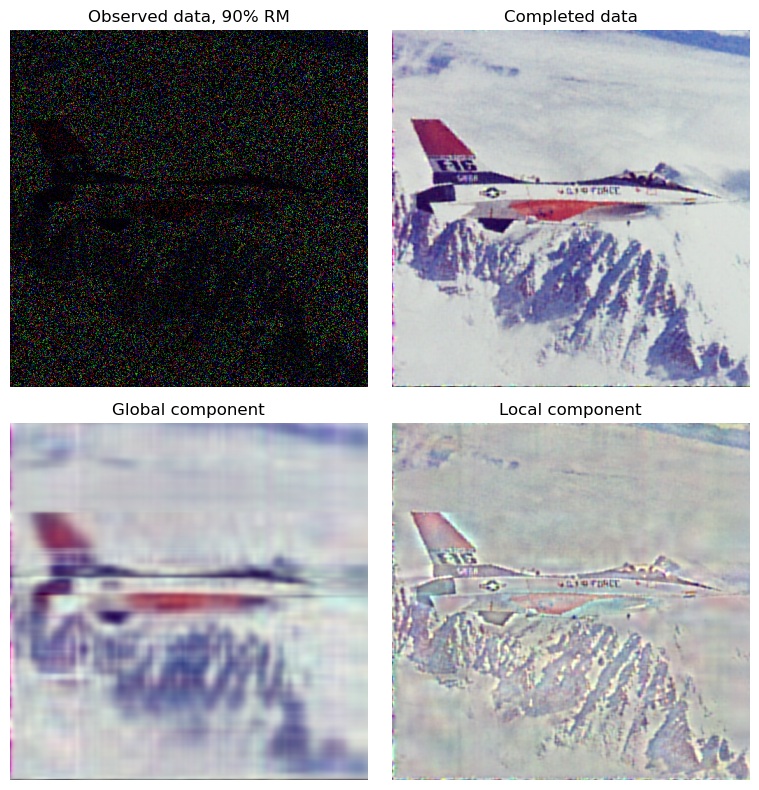

In [4]:
import matplotlib.pyplot as plt

def to_uint8(arr):
    return cp.asnumpy(cp.minimum(255, cp.abs(arr)).astype(cp.uint8))

fig, axes = plt.subplots(2, 2, figsize=(8, 8), tight_layout=True)
axes[0, 0].imshow(to_uint8(I * Omega))
axes[0, 0].set_title('Observed data, 90% RM')
axes[0, 0].set_axis_off()
axes[0, 1].imshow(to_uint8(X))
axes[0, 1].set_title('Completed data')
axes[0, 1].set_axis_off()
axes[1, 0].imshow(to_uint8(Mtensor))
axes[1, 0].set_title('Global component')
axes[1, 0].set_axis_off()
axes[1, 1].imshow(to_uint8(Rtensor))
axes[1, 1].set_title('Local component')
axes[1, 1].set_axis_off()
